# HyDesign Wind Model ” Tests & Visualizations
Tests the three core wind functions and plots their characteristics.

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # for custom subplot layouts
from scipy.stats import weibull_min     # used in Plot 3 to fit wind distribution

from hydesign.look_up_tables import lut_filepath # This is the path to the look-up tables, which are used to get the power curves and wake losses for different turbine configurations.
from hydesign.examples import examples_filepath  # base path to bundled example weather files
from hydesign.tests.test_files import tfp        # base path to golden-reference test CSVs

def get_rotor_area(d):
    return np.pi * (d / 2) ** 2

def get_WT_curves(genWT_fn, specific_power):
    """Loads a single turbine's power curve and thrust coefficient from the surrogate
       look-up table genWT_v3.nc
       Returns the wind speed, power coefficient and
       capacity factor curves for a given specific power.

       Opens the NetCDF file with xarray, interpolates along the sp axis
       to the requested specific power, then closes it. Higher specific_power → flatter,
       later-ramping curve.
       The NetCDF(Network Common Data Form) file is a surrogate model: someone ran thousands of
       simulations beforehand and stored the results. Now you just look up the answer in microseconds.
    """
    # Open surrogate LUT, interpolate to the requested specific power [W/m2]
    genWT = xr.open_dataset(genWT_fn, engine='h5netcdf').interp(
        sp=specific_power, kwargs={'fill_value': 0})  # fill_value=0 outside LUT range
    # Extract 1-D arrays: ws=wind speed axis, pc=normalised power, ct=thrust coefficient
    ws, pc, ct = genWT.ws.values, genWT.pc.values, genWT.ct.values
    genWT.close()  # release file handle
    return ws, pc, ct

def get_wake_affected_pc(genWake_fn, specific_power, Nwt, wind_MW_per_km2, ws, pc, p_rated):
    """
    Loads the wake loss curve for a single turbine from the surrogate look-up table genWake_v3.nc,
    interpolates to the requested specific power, number of turbines, and wind farm density,
    and returns the wake-affected power curve.
    i also prepend the first row of the look-up table with a row of zeros, which corresponds to the
    case of no wake losses (Nwt=1).
    .interp(...) — interpolate across all 4 dimensions at once to get wl at the exact values you requested (e.g. Nwt=101, sp=320, density=7.5)
    fill_value=1 — if outside table range, return wake loss = 1 (100% loss) as a safe fallback
    wl is a numpy array of wake loss fractions, one per wind speed in ws
    """
    # Open the wake-loss surrogate LUT
    ds = xr.open_dataset(genWake_fn, engine='h5netcdf')
    # Grab the Nwt=2 slice so we can prepend a synthetic Nwt=1 (no-wake) row
    ds_sel = ds.sel(Nwt=2)
    ds_sel['wl'] = 0 * ds_sel['wl']  # zero wake loss for a single turbine
    ds_sel['Nwt'] = 1                 # relabel this slice as Nwt=1
    # Prepend the no-wake row so interpolation works all the way down to Nwt=1
    ds = xr.concat([ds_sel, ds], dim='Nwt')
    # Interpolate jointly over all 4 dimensions to get wl at our exact operating point
    gw = ds.interp(ws=ws, sp=float(specific_power), Nwt=float(Nwt),
                   wind_MW_per_km2=float(wind_MW_per_km2), kwargs={'fill_value': 1})
    wl = gw.wl.values  # wake loss fraction per wind speed bin [0..1]
    gw.close()
    # Return absolute farm power: single-turbine curve * (1 - losses) * fleet size * rated MW
    return pc * (1 - wl) * Nwt * p_rated

def get_wind_ts(ws, pcw, wst, wpp_efficiency=0.95):
    """Returns the wake-affected power curve for a given wind speed time series,
    by interpolating the wake-affected power curve to the time series' wind speeds
    and multiplying by the wake-affected power curve's efficiency.
    The wpp_efficiency=0.95 accounts for electrical losses (transformer, cables)
    """
    # Interpolate farm power curve to actual wind speed time series; clamp outside range to 0
    return wpp_efficiency * np.interp(wst, ws, pcw, left=0, right=0)

# Full paths to the two surrogate NetCDF look-up tables used throughout the notebook
genWT_fn   = lut_filepath + 'genWT_v3.nc' # This is the file path to the look-up table for the power curves of different turbine configurations.
genWake_fn = lut_filepath + 'genWake_v3.nc' # This is the file path to the look-up table for the wake losses of different turbine configurations.
print('Imports OK')

Imports OK


## Tests all 3 core functions

In [3]:
# ---- TEST 1: single-turbine curve ------------------------------------------
# Get wind speed array (ws), power curve (pc) and thrust coefficient (ct) for sp=320 W/m2
ws, pc, ct = get_WT_curves(genWT_fn, specific_power=320)
ref1 = pd.read_csv(tfp + 'wind_get_WT_curves_output.csv', index_col=0)  # load golden reference
# Check all three arrays match reference values within numerical tolerance
ok1 = (np.allclose(ws, ref1.ws.values) and
       np.allclose(pc, ref1.pc.values) and
       np.allclose(ct, ref1.ct.values))
print(f'TEST 1 get_WT_curves       : {"PASS" if ok1 else "FAIL"}')

# ---- TEST 2: farm wake-affected power curve ---------------------------------
pcw_ref_df = pd.read_csv(tfp + 'wind_get_wake_affected_pc_output.csv', index_col=0)  # golden reference for wake-affected curve
# Compute wake-affected farm curve: sp=320 W/m2, 101 turbines, 7.5 MW/km2, p_rated=2 MW
pcw_test = get_wake_affected_pc(genWake_fn, 320, 101, 7.5, ws, pc, 2)
# Compare element-wise to reference; allclose uses default rtol=1e-5
ok2 = np.allclose(pcw_test, pcw_ref_df.pcw.values)
print(f'TEST 2 get_wake_affected_pc: {"PASS" if ok2 else "FAIL"}')

# ---- TEST 3: power time series from real weather ----------------------------
# Load hourly weather at hub height 150 m for a good French wind site
weather = pd.read_csv(examples_filepath + 'Europe/GWA2/input_ts_France_good_wind.csv',
                      index_col=0, parse_dates=True)
wst = weather.WS_150.values  # wind speed time series [m/s], 1-h resolution
# Evaluate farm power at each hour using the reference wake-affected curve
wind_ts_ref = get_wind_ts(pcw_ref_df.ws.values, pcw_ref_df.pcw.values, wst, 0.95)
ref3 = pd.read_csv(tfp + 'wind_get_wind_ts_output.csv', index_col=0)  # golden reference time series
ok3 = np.allclose(wind_ts_ref, ref3.wind_ts.values)
print(f'TEST 3 get_wind_ts         : {"PASS" if ok3 else "FAIL"}')
print(f'\nAll tests passed: {ok1 and ok2 and ok3}')

TEST 1 get_WT_curves       : PASS
TEST 2 get_wake_affected_pc: PASS
TEST 3 get_wind_ts         : PASS

All tests passed: True


## Plot 1  Power curve & Ct vs specific power

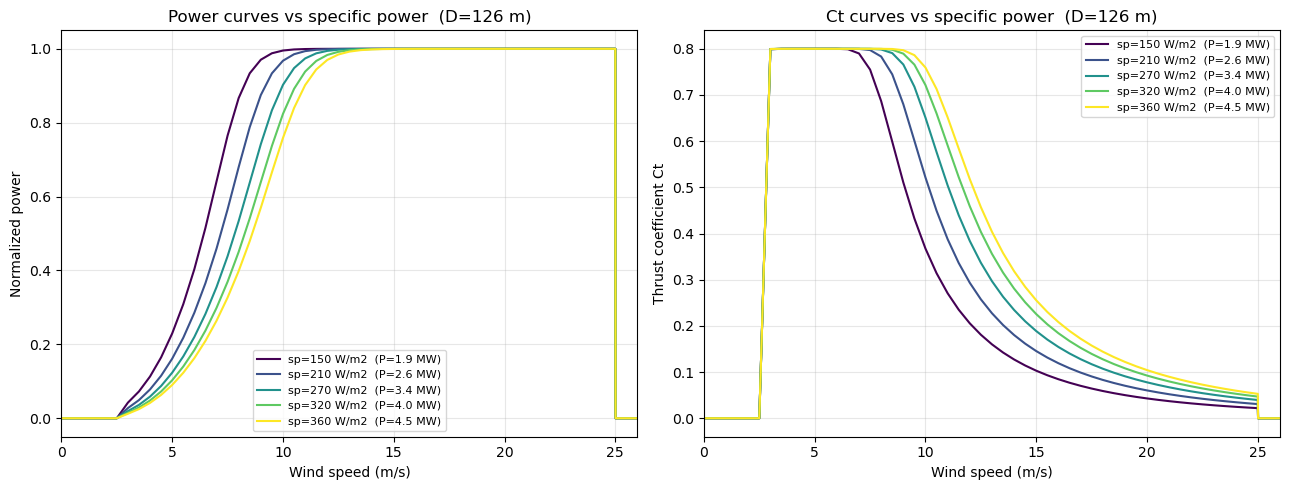

In [5]:
# Specific powers to compare [W/m2] — spans typical onshore to offshore range
specific_powers = [150, 210, 270, 320, 360]
# One colour per specific-power value, sampled from the viridis colourmap
colors = plt.cm.viridis(np.linspace(0, 1, len(specific_powers)))
# Two side-by-side axes: left = power curve, right = Ct curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
d = 126          # rotor diameter [m] — typical IEC class IIA turbine
A = get_rotor_area(d)  # swept area [m2], used to convert W/m2 to absolute MW
# Loop over specific powers and overlay one curve per value
for sp, c in zip(specific_powers, colors):
    # Retrieve normalised power curve and thrust coefficient from LUT
    ws_i, pc_i, ct_i = get_WT_curves(genWT_fn, specific_power=sp)
    p_mw = sp * A / 1e6  # rated power in MW = specific_power [W/m2] * area [m2] / 1e6
    lbl = f'sp={sp} W/m2  (P={p_mw:.1f} MW)'  # legend entry showing both sp and MW
    axes[0].plot(ws_i, pc_i, color=c, label=lbl)  # normalised power vs wind speed
    axes[1].plot(ws_i, ct_i, color=c, label=lbl)  # thrust coefficient vs wind speed
# Apply axis labels, titles, legend, grid, and x-axis limits to both axes
for ax, ylabel, title in zip(axes,
        ['Normalized power', 'Thrust coefficient Ct'],
        ['Power curves', 'Ct curves']):
    ax.set_xlabel('Wind speed (m/s)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} vs specific power  (D={d} m)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 26)  # typical wind speed range up to cut-out ~25 m/s
plt.tight_layout()
plt.show()

## Plot 2  Wake-affected farm power curve vs Nwt and density

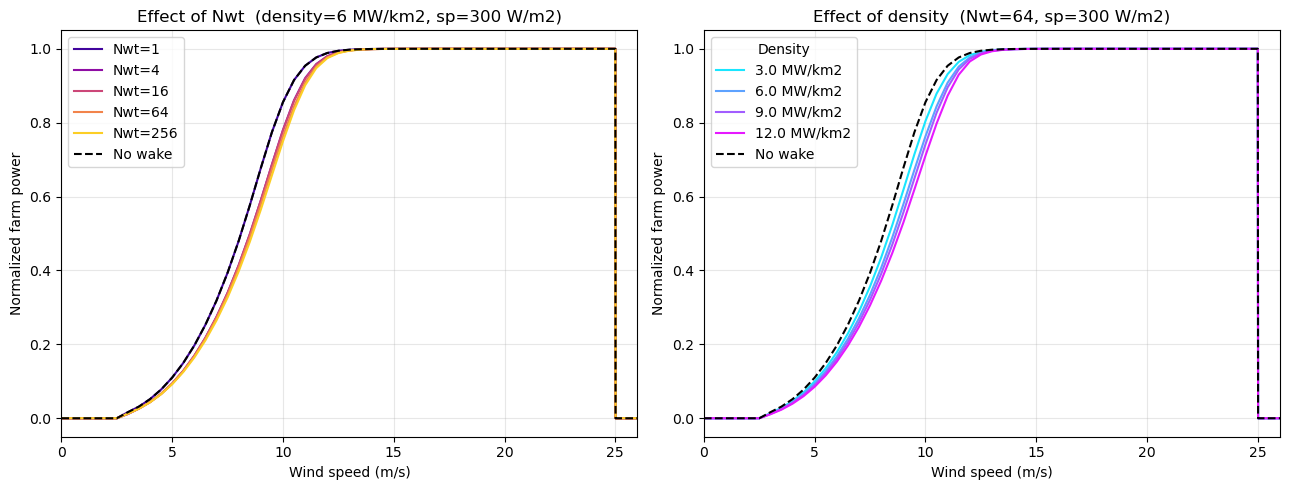

In [6]:
sp = 300      # specific power [W/m2] used throughout this plot
p_rated = 3.0  # rated power per turbine [MW]
# Base single-turbine curve for sp=300; thrust coefficient (3rd return) not needed here
ws_b, pc_b, _ = get_WT_curves(genWT_fn, specific_power=sp)
# Two side-by-side axes: left = vary Nwt, right = vary density
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left panel: effect of number of turbines (fixed density = 6 MW/km2) ----
nwt_list = [1, 4, 16, 64, 256]  # range from a single turbine to a large 768 MW farm
# Iterate over Nwt values with colours from plasma colourmap
for Nwt, c in zip(nwt_list, plt.cm.plasma(np.linspace(0.1, 0.9, len(nwt_list)))):
    # Compute wake-affected absolute farm power curve [MW] for this Nwt
    pcw_i = get_wake_affected_pc(genWake_fn, sp, Nwt, 6.0, ws_b, pc_b, p_rated)
    # Normalise by fleet capacity so all curves are on [0,1] scale for fair comparison
    axes[0].plot(ws_b, pcw_i / (Nwt * p_rated), color=c, label=f'Nwt={Nwt}')
# Dashed black line = ideal single-turbine normalised curve (no wake baseline)
axes[0].plot(ws_b, pc_b, 'k--', lw=1.5, label='No wake')
axes[0].set_title(f'Effect of Nwt  (density=6 MW/km2, sp={sp} W/m2)')
axes[0].legend()

# ---- Right panel: effect of farm density (fixed Nwt = 64) -------------------
density_list = [3.0, 6.0, 9.0, 12.0]  # MW/km2; higher = turbines closer together = more wake
# Iterate over densities with colours from cool colourmap
for dens, c in zip(density_list, plt.cm.cool(np.linspace(0.1, 0.9, len(density_list)))):
    # Compute wake-affected farm curve at fixed fleet of 64 turbines for each density
    pcw_i = get_wake_affected_pc(genWake_fn, sp, 64, dens, ws_b, pc_b, p_rated)
    axes[1].plot(ws_b, pcw_i / (64 * p_rated), color=c, label=f'{dens} MW/km2')
# No-wake baseline for reference
axes[1].plot(ws_b, pc_b, 'k--', lw=1.5, label='No wake')
axes[1].set_title(f'Effect of density  (Nwt=64, sp={sp} W/m2)')
axes[1].legend(title='Density')

# Shared formatting for both axes
for ax in axes:
    ax.set_xlabel('Wind speed (m/s)')
    ax.set_ylabel('Normalized farm power')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 26)
plt.tight_layout()
plt.show()

## Plot 3  Power time series & wind distribution (France good wind)

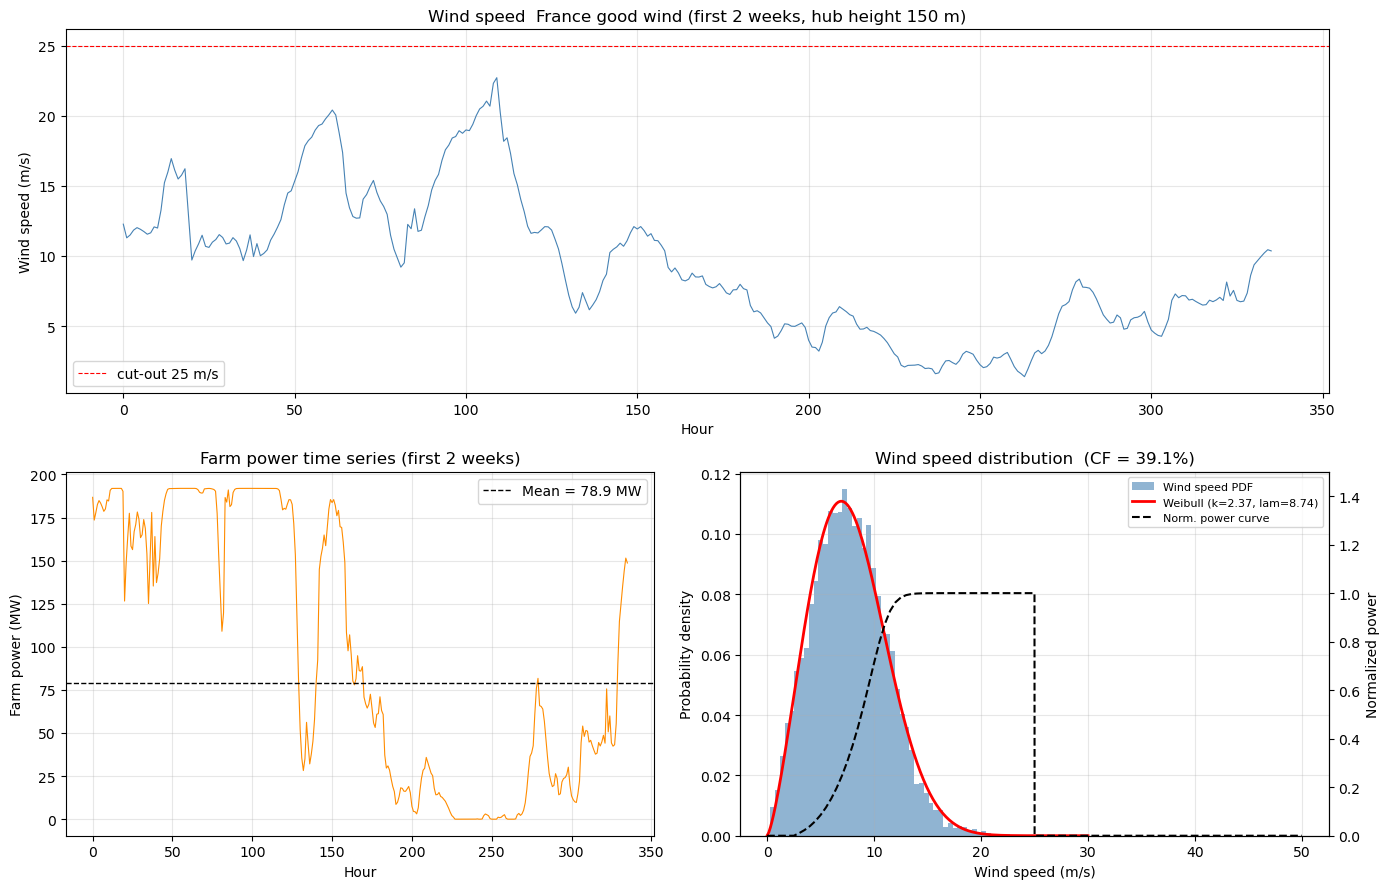

Farm rated power : 202.0 MW
Mean power       : 78.92 MW
Capacity factor  : 39.07%


In [8]:
# Re-use reference wake-affected curve computed in the test cell
ws_ref  = pcw_ref_df.ws.values   # wind speed axis of the reference power curve [m/s]
pcw_ref = pcw_ref_df.pcw.values  # farm power at each wind speed [MW]
# Evaluate hourly farm power for the full weather time series (efficiency = 0.95)
wind_ts = get_wind_ts(ws_ref, pcw_ref, wst, 0.95)

# Create a 2x2 figure with a wide top row spanning both columns
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 2, figure=fig)  # 2-row, 2-column grid for subplot layout

# ---- Top row: wind speed time series (first 2 weeks = 2*7*24 hours) ---------
ax1 = fig.add_subplot(gs[0, :])  # span full width of the top row
t = np.arange(2*7*24)  # time index [hours], 336 hours = 2 weeks
ax1.plot(t, wst[:len(t)], color='steelblue', lw=0.8)  # hourly wind speed [m/s]
ax1.axhline(25, color='red', ls='--', lw=0.8, label='cut-out 25 m/s')  # turbine shut-down threshold
ax1.set_xlabel('Hour')
ax1.set_ylabel('Wind speed (m/s)')
ax1.set_title('Wind speed  France good wind (first 2 weeks, hub height 150 m)')
ax1.legend()
ax1.grid(alpha=0.3)

# ---- Bottom-left: farm power time series (first 2 weeks) --------------------
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, wind_ts[:len(t)], color='darkorange', lw=0.8)  # hourly farm power [MW]
# Horizontal dashed line at long-run mean power
ax2.axhline(wind_ts.mean(), color='k', ls='--', lw=1,
            label=f'Mean = {wind_ts.mean():.1f} MW')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Farm power (MW)')
ax2.set_title('Farm power time series (first 2 weeks)')
ax2.legend()
ax2.grid(alpha=0.3)

# ---- Bottom-right: wind speed PDF + Weibull fit + normalised power curve ----
ax3 = fig.add_subplot(gs[1, 1])
# Histogram of all wind speeds in the full time series, normalised to a probability density
ax3.hist(wst, bins=50, density=True, color='steelblue', alpha=0.6, label='Wind speed PDF')
# Fit a Weibull distribution to positive wind speeds (floc=0 fixes location to zero)
c_fit, loc_fit, scale_fit = weibull_min.fit(wst[wst > 0], floc=0)
ws_plot = np.linspace(0, 30, 200)  # smooth x-axis for the Weibull PDF line
# Overlay fitted Weibull PDF; k=shape (c_fit), lambda=scale (scale_fit)
ax3.plot(ws_plot, weibull_min.pdf(ws_plot, c_fit, loc_fit, scale_fit),
         'r-', lw=2, label=f'Weibull (k={c_fit:.2f}, lam={scale_fit:.2f})')
ax3b = ax3.twinx()  # second y-axis for normalised power curve overlay
# Overlay normalised farm power curve on the shared x-axis (wind speed)
ax3b.plot(ws_ref, pcw_ref / pcw_ref.max(), 'k--', lw=1.5, label='Norm. power curve')
ax3b.set_ylabel('Normalized power')
ax3b.set_ylim(0, 1.5)  # headroom above 1 prevents overlap with histogram bars
ax3.set_xlabel('Wind speed (m/s)')
ax3.set_ylabel('Probability density')
# Capacity factor [%] = mean output / rated capacity
cf = wind_ts.mean() / pcw_ref.max() * 100
ax3.set_title(f'Wind speed distribution  (CF = {cf:.1f}%)')
# Combine legend handles from both axes into a single legend
lines = ax3.get_legend_handles_labels()[0] + ax3b.get_legend_handles_labels()[0]
labels = ax3.get_legend_handles_labels()[1] + ax3b.get_legend_handles_labels()[1]
ax3.legend(lines, labels, fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# Print summary statistics for the farm
print(f'Farm rated power : {pcw_ref.max():.1f} MW')
print(f'Mean power       : {wind_ts.mean():.2f} MW')
print(f'Capacity factor  : {wind_ts.mean()/pcw_ref.max():.2%}')

## Plot 4  Wake losses vs farm size and density

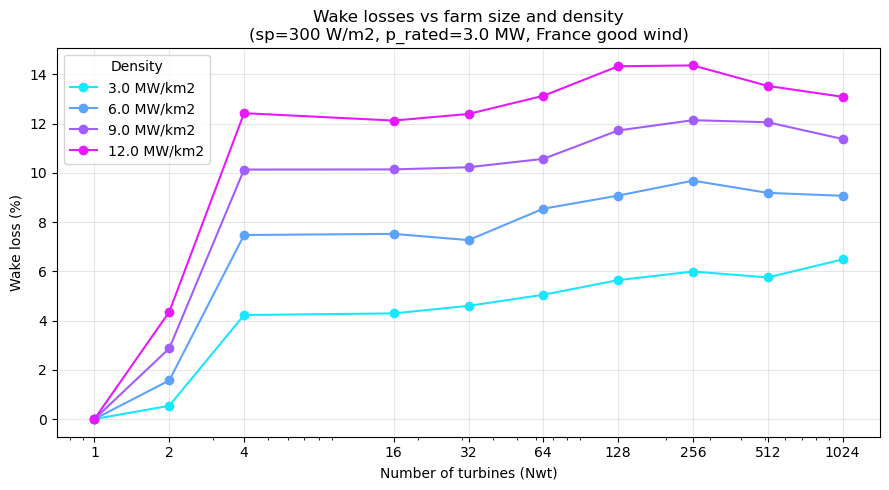

In [9]:
sp = 300       # specific power [W/m2] for this analysis
p_rated = 3.0   # rated power per turbine [MW]
# Base single-turbine curve; thrust coefficient not needed (ignored with _)
ws_b, pc_b, _ = get_WT_curves(genWT_fn, specific_power=sp)
# Baseline capacity factor with no wake losses and no electrical losses (efficiency=1)
cf_nowake = get_wind_ts(ws_b, pc_b, wst, 1.0).mean()

# Farm sizes and densities to sweep
nwt_vals     = [1, 2, 4, 16, 32, 64, 128, 256, 512, 1024]  # number of turbines (log scale)
density_vals = [3.0, 6.0, 9.0, 12.0]  # farm density [MW/km2]

# Single axes; x-axis will be log-scaled for readability
fig, ax = plt.subplots(figsize=(9, 5))
# Outer loop: one line per density, colour from cool colourmap
for dens, c in zip(density_vals, plt.cm.cool(np.linspace(0.1, 0.9, len(density_vals)))):
    wake_losses = []
    # Inner loop: compute wake loss % at each farm size
    for nwt in nwt_vals:
        # Absolute wake-affected farm power curve [MW] for this (nwt, density) pair
        pcw_i = get_wake_affected_pc(genWake_fn, sp, nwt, dens, ws_b, pc_b, p_rated)
        # Normalise to per-turbine capacity factor before passing to get_wind_ts
        cf_i  = get_wind_ts(ws_b, pcw_i / (nwt * p_rated), wst, 0.95).mean()
        # Wake loss = relative drop vs no-wake CF (0.95 accounts for electrical losses)
        wake_losses.append((1 - cf_i / (0.95 * cf_nowake)) * 100)
    # Plot wake loss curve as markers + line for this density
    ax.plot(nwt_vals, wake_losses, 'o-', color=c, label=f'{dens} MW/km2')

ax.set_xscale('log')  # log scale highlights the rapid increase at small Nwt
ax.set_xlabel('Number of turbines (Nwt)')
ax.set_ylabel('Wake loss (%)')
ax.set_title(f'Wake losses vs farm size and density\n(sp={sp} W/m2, p_rated={p_rated} MW, France good wind)')
ax.legend(title='Density')
ax.grid(alpha=0.3)
# Explicit tick labels so all nwt values appear on log axis
ax.set_xticks(nwt_vals)
ax.set_xticklabels(nwt_vals)
plt.tight_layout()
plt.show()

## Capability 4 — Turbine Degradation Modelling

Wind turbines degrade over their 25-year lifetime.  Two mechanisms are available and can be blended:

| `share_WT_deg_types` | Mechanism |
|---|---|
| `0` | **Power curve shift** — cut-in and rated wind speeds increase gradually; hurts low-wind capture |
| `1` | **Loss factor** — uniform efficiency reduction at all wind speeds |
| `0.5` *(default)* | **Blend** of both mechanisms |

The degradation curve is defined as `(wind_deg_yr, wind_deg)` — cumulative fractional losses at each year.

(0.0, 25.0)

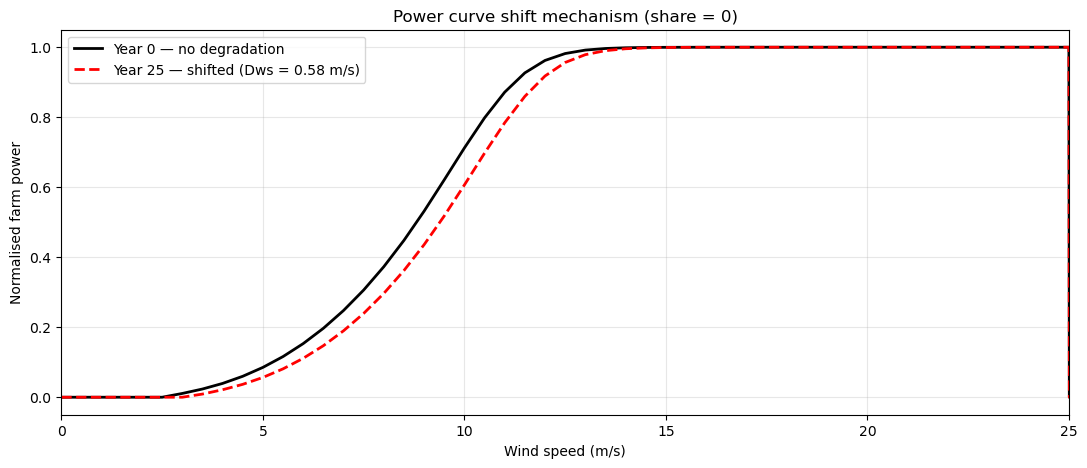

In [ ]:
import scipy as sp  # needed for sp.optimize.minimize in get_Dws
#hese functions are from hydesign — they live in wind.py:529-600.
# They were copied inline into your notebook only to avoid the openmdao→JAX import error
# (as explained in your memory notes).
#The only change made during our session was inside get_Dws: the original returns out.x
# (a 1-element array), which was changed to float(out.x[0]) to fix a TypeError.

#So the model logic is 100% HyDesign's. The notebook just carries local copies of those functions.

def get_prated_end(ws, pc, tol=1e-6):
    """
    Returns the index of the last wind speed bin in the power curve that is effectively at rated power,
    by looking for the last bin where the power curve is flat (slope <= tol) and
    close to 1 (>= 1 - tol) after normalizing the power curve to its
    maximum. If no rated region is found, returns -3 as a flag value.
    """
    if np.max(pc) > 0:
        pc = pc / np.max(pc)  # normalise so rated = 1.0
        # Find indices where curve is both flat (not rising) and at full power
        ind = np.where((np.diff(pc) <= tol) & (pc[:-1] >= 1 - tol))[0]
        return ind[-1]  # last such index marks end of rated plateau
    return -3  # fallback flag: no valid rated region found

def get_shifted_pc(ws, pc, Dws):
    """
    Returns a power curve shifted by Dws, by keeping the original power curve up to the rated region,
    then shifting the rest by Dws. The shift is implemented by finding the wind speed bin where the
    rated region ends,
    interpolating the power curve to ws + Dws, and then
    replacing the power curve values after the rated region with the shifted values.
    """
    # Index of the last bin in the rated plateau (above this, curve stays flat)
    ind_sel = get_prated_end(ws, pc)
    # Interpolate original curve onto ws+Dws grid to simulate cut-in wind speed shift
    pcdeg_init = get_wind_ts(ws=ws + Dws, pcw=pc, wst=ws, wpp_efficiency=1)
    pcdeg = np.copy(pcdeg_init)  # mutable copy so we can splice in the rated region
    # Restore rated-region values — degradation only lowers sub-rated output
    pcdeg[ind_sel:] = pc[ind_sel:]
    return pcdeg

def get_losses_shift_pc(ws, pc, ws_ts, Dws):
    """
    simulate the full year with the original and the shifted curve,
    compare the average capacity factors. Returns the fractional energy
    loss caused by shift Dws.
    """
    # Baseline mean capacity factor with the undegraded curve
    CF_ref = np.mean(get_wind_ts(ws=ws, pcw=pc, wst=ws_ts, wpp_efficiency=1))
    if CF_ref > 0:
        # Mean CF with the shifted (degraded) power curve
        CF_deg = np.mean(get_wind_ts(ws=ws, pcw=get_shifted_pc(ws, pc, Dws), wst=ws_ts, wpp_efficiency=1))
        return 1 - CF_deg / CF_ref  # fractional energy loss [0..1]
    return np.nan  # undefined if there is no wind at all

def get_Dws(ws, pc, ws_ts, wind_deg_end):
    """
    Find the Dws that causes a shift loss equal to the target wind_deg_end,
    by simulating the full year with the original and the shifted curve, comparing the
    average capacity factors, and using a numerical optimizer to find the Dws that gives
    the desired loss.
    """
    CF_ref = np.mean(get_wind_ts(ws=ws, pcw=pc, wst=ws_ts, wpp_efficiency=1))
    if CF_ref > 0:
        # Objective: squared difference between modelled loss and target loss
        def fun(x, target): return (get_losses_shift_pc(ws, pc, ws_ts, Dws=x) - target) ** 2
        # SLSQP minimiser; x0=0.5 m/s is a reasonable initial guess for the shift
        out = sp.optimize.minimize(fun=fun, x0=0.5, args=(wind_deg_end,), method="SLSQP", tol=1e-10)
        return float(out.x[0])  # scalar shift value [m/s] that achieves target loss
    return 0.0  # no degradation if farm CF is zero

def get_wind_ts_degradation(ws, pc, ws_ts, yr, wind_deg, life, share=0.5, intervals_per_hour=1):
    # Map cumulative degradation curve (yr, wind_deg) onto each operational year
    t_over_year = np.arange(life) / (365 * 24 * intervals_per_hour)  # year fraction per timestep
    degradation = np.interp(t_over_year, yr, wind_deg)  # interpolated loss at each year
    # Power time series with undegraded curve (year-0 baseline)
    p_ts = get_wind_ts(ws=ws, pcw=pc, wst=ws_ts, wpp_efficiency=1)
    # Optimal wind speed shift that reproduces end-of-life (year 25) loss target
    Dws = get_Dws(ws, pc, ws_ts, wind_deg_end=degradation[-1])
    # Power curve at full degradation (year 25 shifted curve)
    pcdeg = get_shifted_pc(ws, pc, Dws=Dws)
    # Power time series with fully-degraded curve
    p_ts_fulldeg = get_wind_ts(ws=ws, pcw=pcdeg, wst=ws_ts, wpp_efficiency=1)
    # alpha ramps from 0 (year 0) to 1 (year 25) — blends baseline and degraded time series
    alpha = 0 if np.max(wind_deg) <= 0 else degradation / np.max(degradation)
    # Blended time series accounting for gradual curve shift over lifetime
    p_ts_deg = (1 - alpha) * p_ts + alpha * p_ts_fulldeg
    # Final output: (1-share) uses curve-shift mechanism, share uses uniform loss-factor mechanism
    return (1 - share) * p_ts_deg + share * (1 - degradation) * p_ts


# Use the reference farm power curve from earlier cells (101 turbines, 7.5 MW/km2)
ws_d   = pcw_ref_df.ws.values
pcw_d  = pcw_ref_df.pcw.values   # farm wake-affected power curve [MW]
p_farm = pcw_d.max()  # farm rated (peak) power [MW] — used for normalisation

# Degradation scenario: 0.5 %/yr cumulative -> 12.5 % total at year 25
life_y      = 25           # design lifetime [years]
wind_deg_yr = [0, 25]      # year breakpoints for the degradation curve
wind_deg    = [0.0, 0.125] # cumulative fractional energy loss at each breakpoint (0% at yr 0, 12.5% at yr 25)

# -- 1. Power curve shift at year 25 -------------------------------------
# Find the wind speed shift Dws [m/s] that reproduces the 12.5% end-of-life loss
Dws_opt    = get_Dws(ws_d, pcw_d, wst, wind_deg_end=wind_deg[-1])
# Apply that shift to obtain the year-25 degraded power curve
pc_shifted = get_shifted_pc(ws_d, pcw_d, Dws=Dws_opt)

fig, axes = plt.subplots(1, 1, figsize=(13, 5))
# Year-0 (undegraded) normalised farm power curve
axes.plot(ws_d, pcw_d    / p_farm, 'k-',  lw=2, label='Year 0 — no degradation')
# Year-25 (fully degraded) normalised farm power curve; label shows solved Dws
axes.plot(ws_d, pc_shifted / p_farm, 'r--', lw=2,
             label=f'Year 25 — shifted (Dws = {Dws_opt:.2f} m/s)')
axes.set_xlabel('Wind speed (m/s)');
axes.set_ylabel('Normalised farm power')
axes.set_title('Power curve shift mechanism (share = 0)')
axes.legend(); axes.grid(alpha=0.3); axes.set_xlim(0, 25)


## Capability 5 — 2D Directional Power Curves

`get_wind_ts_2d` maps a **(wind speed, wind direction) → farm power** surface instead of a 1-D curve.
This matters when wake losses are asymmetric — e.g. turbines aligned along the prevailing wind direction
incur higher losses from that sector.

A 2-D farm power curve `pcw_2d[n_wd, n_ws]` is built here by running the surrogate wake model for
each direction sector with a direction-dependent effective turbine count (simulating varying wake alignment).

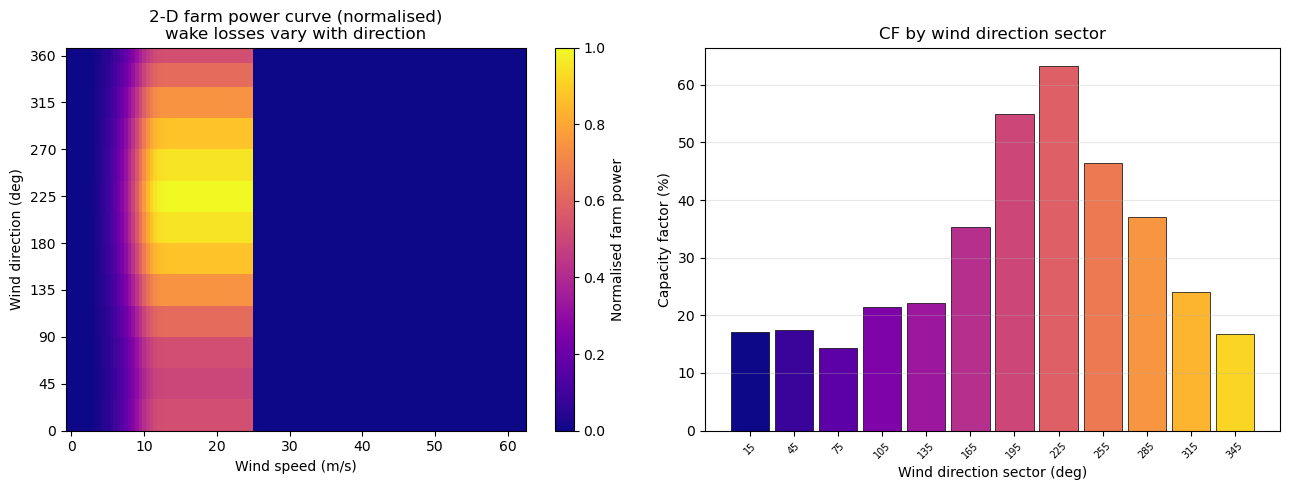

1-D model (direction-averaged)  AEP: 692 GWh/yr
2-D model (directional pcw)     AEP: 589 GWh/yr
Difference: -14.9% (negative = extra losses from worst-case alignment sector)


In [11]:
from hydesign.wind.wind import get_wind_ts_2d  # 2-D interpolation: (ws, wd) -> farm power

# Load wind speed and direction time series at hub height 150 m
weather_df = pd.read_csv(
    examples_filepath + 'Europe/GWA2/input_ts_France_good_wind.csv',
    index_col=0, parse_dates=True)
wst_full = weather_df.WS_150.values  # wind speed time series [m/s]
wdt_full = weather_df.WD_150.values  # wind direction time series [deg, meteorological]

# Direction sectors: 0 to 360 in steps of 30 deg (12 sectors + closing point)
n_wd_bins  = 12                                          # number of directional sectors
wd_edges   = np.linspace(0, 360, n_wd_bins + 1)   # 0, 30, ..., 360
wd_centers = (wd_edges[:-1] + wd_edges[1:]) / 2    # 15, 45, ..., 345

sp_5 = 300; p_rated_5 = 3.0; Nwt_ref = 64  # turbine spec and reference fleet size
# Single-turbine LUT lookup for this specific power (thrust coeff discarded)
ws_5, pc_5, _ = get_WT_curves(genWT_fn, specific_power=sp_5)

# Build 2-D power curve: wake losses vary by direction.
# Prevailing wind from SW (225 deg) -> turbines aligned there see highest wakes.
# Shape: (n_wd_bins + 1, n_ws) — the +1 row closes the 360/0 wrap-around
pcw_2d_norm = np.zeros((n_wd_bins + 1, len(ws_5)))
for i, ang in enumerate(wd_centers):
    # alignment=1 when wind is exactly from SW (225 deg), =0 for perpendicular directions
    alignment = 0.5 + 0.5 * np.cos(np.radians(ang - 225))
    # Effective turbine count rises with alignment (more turbines in the wake shadow)
    Nwt_eff = max(4, int(Nwt_ref * (0.5 + 0.5 * alignment)))  # 32 to 64
    # Absolute farm power curve [MW] for this direction's effective turbine count
    pcw_i = get_wake_affected_pc(genWake_fn, sp_5, Nwt_eff, 6.0, ws_5, pc_5, p_rated_5)
    # Store as normalised fraction of full-fleet rated capacity
    pcw_2d_norm[i] = pcw_i / (Nwt_ref * p_rated_5)
pcw_2d_norm[-1] = pcw_2d_norm[0]          # close circle: 360 deg == 0 deg

# Convert normalised 2-D curve to absolute [MW] for get_wind_ts_2d input
pcw_2d_abs = pcw_2d_norm * (Nwt_ref * p_rated_5)  # absolute [MW]
# Direction axis including the closing 360 point; matches first dimension of pcw_2d arrays
wd_axis    = np.append(wd_centers, 360.0)           # add 360 closing point

# -- Plot: 2-D power surface and directional CF -------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: colour map of normalised farm power over (wind speed, wind direction) space
im = axes[0].pcolormesh(ws_5, wd_axis, pcw_2d_norm, shading='auto', cmap='plasma')
plt.colorbar(im, ax=axes[0], label='Normalised farm power')  # colour bar for power scale
axes[0].set_xlabel('Wind speed (m/s)'); axes[0].set_ylabel('Wind direction (deg)')
axes[0].set_title('2-D farm power curve (normalised)\nwake losses vary with direction')
axes[0].set_yticks(np.arange(0, 361, 45))  # tick every 45 deg (N, NE, E, SE, ...)

# Right: bar chart of capacity factor per direction sector computed from actual weather
for i, ang in enumerate(wd_centers):
    # Boolean mask selecting all hours where wind is in this 30-deg sector
    mask = (wdt_full >= wd_edges[i]) & (wdt_full < wd_edges[i + 1])
    if mask.sum() > 0:
        # Mean normalised power for hours in this sector = directional CF
        cf_i = np.mean(get_wind_ts(ws_5, pcw_2d_norm[i], wst_full[mask], wpp_efficiency=1))
        # Bar width 26 deg leaves small gaps between the 30-deg-wide sectors
        axes[1].bar(ang, cf_i * 100, width=26, color=plt.cm.plasma(i / n_wd_bins),
                    edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Wind direction sector (deg)'); axes[1].set_ylabel('Capacity factor (%)')
axes[1].set_title('CF by wind direction sector')
axes[1].set_xticks(wd_centers)
axes[1].set_xticklabels([f'{a:.0f}' for a in wd_centers], rotation=45, fontsize=7)
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# -- Compare 1-D vs 2-D AEP ---------------------------------------------
# Clip direction values to stay within the wd_axis range [0, 360] to avoid extrapolation
wdt_clipped = np.clip(wdt_full, wd_axis[0], wd_axis[-1])
# 1-D benchmark: direction-averaged single wake-loss curve for the whole farm
pcw_1d = get_wake_affected_pc(genWake_fn, sp_5, Nwt_ref, 6.0, ws_5, pc_5, p_rated_5)
# 1-D power time series [MW] using the direction-averaged curve
wind_ts_1d = get_wind_ts(ws_5, pcw_1d, wst_full, wpp_efficiency=0.95)
# 2-D power time series [MW]: interpolates over (ws, wd) surface at each hour
wind_ts_2d = get_wind_ts_2d(ws=ws_5, wd=wd_axis, pcw=pcw_2d_abs,
                              wst=wst_full, wdt=wdt_clipped, wpp_efficiency=0.95)

# Annual energy production [GWh/yr] = mean power [MW] * hours in dataset / 1000
aep_1d = wind_ts_1d.mean() * len(wst_full) / 1e3
aep_2d = wind_ts_2d.mean() * len(wst_full) / 1e3
print(f'1-D model (direction-averaged)  AEP: {aep_1d:.0f} GWh/yr')
print(f'2-D model (directional pcw)     AEP: {aep_2d:.0f} GWh/yr')
# Positive difference = 2-D model captures higher-producing sectors; negative = extra losses
print(f'Difference: {(aep_2d - aep_1d)/aep_1d*100:+.1f}% '
      '(negative = extra losses from worst-case alignment sector)')